In [2]:
import ase
import matplotlib.pyplot as plt
from ase.io import read
import numpy as np
import abtem

(array([ 0.        , -0.        , -0.08229234]), array([1.05177735, 1.0339559 , 0.69541029]), array([-0.08108108,  0.        ,  0.        ]))
Cell([20.0, 20.0, 5.0])
[74 16 16 74 16 16 74 16 16 16 16 74 16 16 74 16 16 74 16 16 74 16 16 16
 16 74 16 16 74 16 16 74 16 16 74 16 16 74 16 16 74 16 16 16 16 74 16 16
 74 16 16 74 16 16 74 16 16 74 16 16 74 16 16 74 16 16 74 16 16 74 16 16
 74 16 16 74 16 16 74 16 16 74 16 16 74 16 16 74 16 16 74 16 16 74 16 16
 74 16 16 74 16 16 74 16 16 74 74 16 16 74 16 16 74 16 16 74 16 16 74 74
 16 16 74 16 16 74]


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

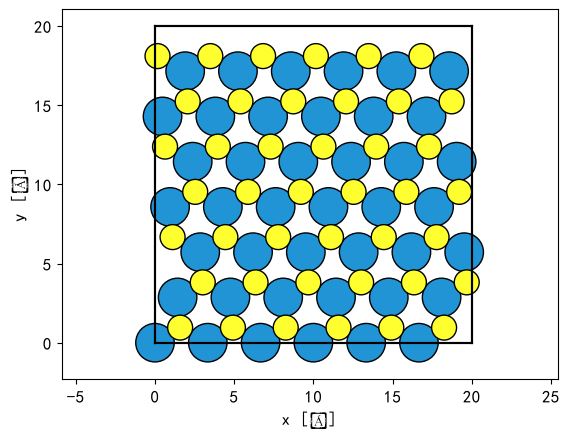

In [ ]:
from ase.build.surface import mx2
atoms = mx2("WS2", vacuum=2)
#print(atoms.cell)
atoms,transform = abtem.orthogonalize_cell(atoms,return_transform=True,box=[20,20,5])
print(transform)
print(atoms.cell)

print(atoms.)
abtem.show_atoms(atoms)


Original Cell: Cell([3.18, 5.50792156806903, 7.1899999999999995])
Original Positions: [[0.         0.         3.595     ]
 [1.59       0.91798693 5.19      ]
 [1.59       0.91798693 2.        ]
 [0.         3.67194771 5.19      ]
 [0.         3.67194771 2.        ]
 [1.59       2.75396078 3.595     ]]
Original Info: {}
Transformed Cell: Cell([28.62, 27.53960784034515, 7.1899999999999995])
Applied Transform: (array([ 0., -0.,  0.]), array([1., 1., 1.]), array([0., 0., 0.]))


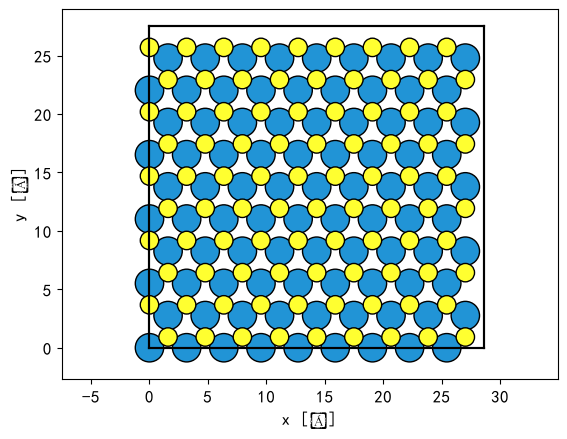

In [ ]:
abtem.config.set(
    {"device":"gpu",     
     "fft": "fftw",
    "diagnostics.task_progress": False,
     "diagnostics.progress_bar": False,
    }
)
import inspect

from ase.build.surface import mx2
atoms = mx2("WS2", vacuum=2)

atoms,transform = abtem.orthogonalize_cell(atoms,return_transform=True)

print(f"Original Cell: {atoms.cell}")
print(f"Original Positions: {atoms.get_positions()}")
atoms = atoms * (9, 5, 1)
print(f"Transformed Cell: {atoms.cell}")
abtem.show_atoms(atoms)
print(f"Applied Transform: {transform}")

## Potential

In [3]:
frozen_phonons = abtem.FrozenPhonons(atoms, 8, sigmas=0.1)
potential=abtem.Potential(frozen_phonons,sampling=0.05)

## Wavefunction

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


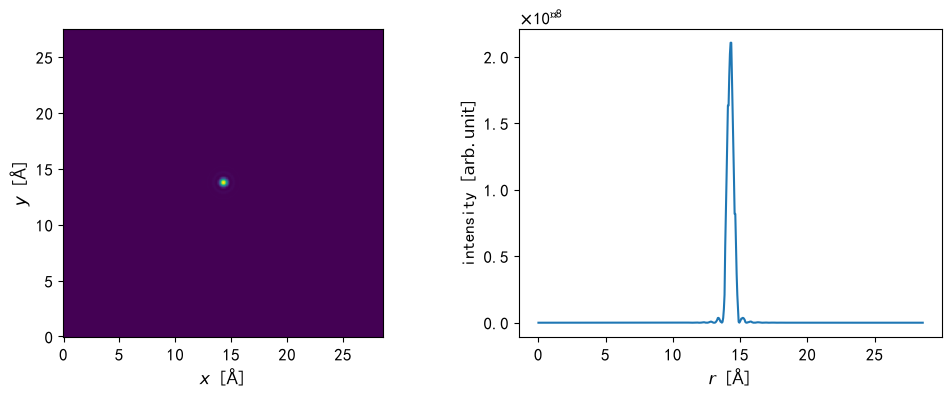

In [4]:
probe = abtem.Probe(energy=200e3, semiangle_cutoff=23)
probe.grid.match(potential)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
probe.show(ax=ax1)
probe.profiles().show(ax=ax2);

## Scan

常规栅格扫描,起止可以是分数,浮点数，浮点数元组或者是ASE原子对象（默认取其atom.x,atom.y）

`fractional=True` 时 start/end 在构造时即换算为 Å（乘 potential 的 extent）。`GridScan` 只是"描述"：`extent`/`gpts`/`sampling` 至少两个，缺的由 `Grid` 推导。显式给 `sampling` 时按 `ceil(extent/sampling)` 定每轴点数，再反推实际采样（各轴略有出入）；不给时 `probe.scan()` 在**副本**上按 probe 的 Nyquist（`0.99·λ/(4·semiangle)`）自动定——原对象不受影响。

In [5]:
grid_scan= abtem.GridScan(
    start=[0,0],end=[1/9,1/5],fractional= True,potential=potential
)

In [6]:
print("match 前:", grid_scan.sampling, grid_scan.gpts)

reference_scan = grid_scan.copy()
reference_scan.match_probe(probe)  # 未给 sampling 时按 probe 的 Nyquist 自动定；probe.scan 内部同样是在副本上匹配

print(f"match 后: {reference_scan.sampling}, {reference_scan.gpts}")
raster = reference_scan.get_positions()  # (nx, ny, 2) [Å]
print("raster:", raster.shape)

match 前: None None
match 后: (0.26499999999999996, 0.26228197943185855), (12, 21)
raster: (12, 21, 2)


In [ ]:
perturbation_raster = raster + np.random.normal(0, 0.2, raster.shape)
custom_scan = abtem.CustomScan(perturbation_raster.reshape(-1, 2))  # CustomScan 只接受 (N, 2) 的拍平位置
print("custom_scan:", custom_scan.shape)

## Detect

scan接受的对象可以是BaseScan或者 Sequence，GridScan继承自BaseScan，返回BaseMeasurements or list of BaseMeasurements.

In [ ]:
detector=abtem.PixelatedDetector(max_angle= 27.5)

measurements = probe.scan(potential, scan=grid_scan, detectors=detector)

measurements.array

In [ ]:
print(measurements.sampling)

In [ ]:
measurements.to_zarr("4d-stem_quickstart.zarr", compute=True);

使用compute方法将写入disk的模拟结果读回mem.

In [ ]:
measurements = abtem.from_zarr("4d-stem_quickstart.zarr").compute()

## PostProcessing

通过高斯blur模拟空间部分相干性，$\sigma=0.3 \AA$。 部分时间相干性在此忽略。


下面展示其中一张衍射

In [ ]:
filtered_measurements = measurements.gaussian_source_size(0.3)

noisy_measurements = filtered_measurements.poisson_noise(dose_per_area=1e6)

abtem.stack((noisy_measurements[0, 0], noisy_measurements[0, 0].block_direct())).show(
    explode=True, title=None
)

In [ ]:
visualization = (
    noisy_measurements[::2, ::2]
    .crop(60)
    .block_direct()
    .show(explode=True, figsize=(8, 8), title=None)
)
visualization.axes.set_sizes(padding=0.05)

MAADF

In [ ]:
abf = (
    filtered_measurements.integrate_radial(0,27)
    .interpolate(0.05)
    .tile((9, 5))
    .poisson_noise(dose_per_area=1e5)
)

abf.show();

COM和iCOM

In [ ]:
center_of_mass = filtered_measurements.center_of_mass()

interpolated_center_of_mass = center_of_mass.interpolate(0.05).tile((3, 2))

interpolated_center_of_mass.show(cbar=True, vmax=0.015, vmin=0);